## 🐻‍❄️ 투빅스 25&26기 5주차 2교시 — CLIP 직접 구현 & Modality Gap 관찰

#### ✅ 과제 목적
멀티모달 표현학습에서 가장 널리 쓰이는 CLIP(Radford et al., 2021)을 처음부터 직접 만들어 봅니다.
서로 다른 데이터로 각자 학습된 두 unimodal encoder를 가져와, 논문이 제안한 구조 그대로
projection, learnable temperature, symmetric InfoNCE를 구현하고 학습시킵니다.

직접 만든 CLIP이 어느 정도 정렬에 성공하고 나면, 그 정렬이 실제로 얼마나 "완전한"지 되짚어 보는
심화 선택 파트가 이어집니다. 사전학습이 훨씬 많이 된 공개 CLIP조차 이미지와 텍스트 embedding을
완전히 같은 자리에 겹쳐 놓지는 못한다는 modality gap 현상(Liang et al., 2022)을 직접 눈으로 확인합니다.

> - **Part A. CLIP 직접 구현 (필수)** — 서로 다른 두 unimodal encoder를 가져와 projection, learnable temperature,
>   symmetric InfoNCE를 직접 짜고 학습시킵니다.
> - **Part B. Modality Gap 관찰 (심화 선택)** — 사전학습 CLIP을 불러와 정렬 이후에도 남아 있는 gap을 시각화하고 측정합니다.

> 이 노트북은 아래 두 논문을 그대로 따라갑니다. CLIP Part는 논문과제 및 세션과제와 연관지어 활용하시면 됩니다.
> - CLIP: Radford et al., [Learning Transferable Visual Models From Natural Language Supervision](https://arxiv.org/abs/2103.00020) (2021)
> - Modality Gap: Liang et al., [Mind the Gap: Understanding the Modality Gap in Multi-modal Contrastive Representation Learning](https://arxiv.org/abs/2203.02053) (NeurIPS 2022)

> **데이터셋:** [Flickr8k](https://huggingface.co/datasets/jxie/flickr8k) (Hugging Face `jxie/flickr8k`)
> - 이미지 8,000장(train 6,000 / val 1,000 / test 1,000), 이미지 하나당 caption 5개
> - Part A는 train 2,000장, test 500장을, Part B는 test에서 300장을 사용합니다.

> **Part A에서 사용하는 encoder:**
> - 이미지: `google/vit-base-patch16-224-in21k` — ImageNet-21k 이미지 분류로만 학습 (텍스트를 본 적 없음)
> - 텍스트: `distilbert-base-uncased` — 영어 텍스트 코퍼스로만 학습 (이미지를 본 적 없음)
> - 두 encoder 모두 이미지-텍스트 쌍을 함께 본 적이 없습니다. Alignment 부분은 우리가 처음부터 만들어야 합니다.
> - 두 encoder는 backbone을 froze 하고 feature만 뽑아 씁니다. 우리가 학습하는 부분은 그 위에 올라가는 얇은 층뿐입니다.

> **Part B에서 사용하는 모델:** `openai/clip-vit-base-patch32` — 이미지-텍스트 쌍으로 이미 학습이 끝난 공개 체크포인트

#### ✅ 주의 사항
> - 코드 셀의 `# ===== TODO n =====` 블록을 순서대로 채우세요.
> - ⚠️ Hugging Face에서 데이터셋을 내려받으므로 토큰 로그인이 되어 있어야 합니다.
> - `MY_SEED`(본인 학번 뒷 4자리)를 꼭 채우세요.
> - 자체 GPU 혹은 Colab GPU 런타임을 활용하세요.
> - Part A의 서술형 문제는 총 2문항, Part B(심화 선택)는 1문항입니다. 모두 본인이 직접 실행한 결과를 활용해 답변하시면 됩니다.

#### ✅ 제출물
> - Part A: 빈칸을 모두 채우고 전부 실행한 이 노트북 (출력 포함) — 필수
> - Part B: 선택과제
> - 기술블로그 '과제 복습' 섹션 — 이번 실습에서 CLIP 논문의 어느 부분을 구현했는지 정리

### 🗺️ 실습 흐름

> **Part A. CLIP 직접 구현 (필수)**
0. 환경 설정
1. 데이터 준비
2. 두 개의 unimodal encoder에서 feature 추출
3. Heterogeneity Gap 확인 — 정렬 전 두 공간은 왜 그냥 비교할 수 없는가
4. 준비 — 작은 예시로 정렬의 핵심 아이디어 먼저 만져보기
5. Projection — 두 공간을 잇는 다리
6. Learnable Temperature — 유사도를 얼마나 뾰족하게 볼 것인가
7. 손실함수, 절반만 — 한쪽 방향만 맞추면 생기는 일
8. Symmetric InfoNCE — CLIP의 완성된 손실함수
9. 학습 전후 retrieval 비교
10. 학습된 모델이 어떻게 맞히고 틀리는지 보기

> **Part B. Modality Gap 관찰 (심화 선택)**
11. 사전학습 CLIP 불러오기 & embedding 뽑기
12. 두 modality가 실제로 겹쳐 있는지 시각화
13. Gap은 학습 때문에 생기는가, 초기화 때문에 생기는가
14. Gap을 숫자로 재보기

### 📖 논문 대응표

| 노트북 | 논문 근거 |
|---|---|
| 3장 Heterogeneity Gap | CLIP 논문 Section 1 — 서로 다르게 사전학습된 encoder는 같은 벡터 공간을 공유하지 않는다는 문제의식 |
| 5장 Projection | CLIP 논문 Section 2.3, Figure 3의 `W_i`, `W_t`. "우리는 linear projection만 사용했다"는 저자들의 명시적 선택 |
| 6장 Learnable Temperature | CLIP 논문 Section 2.5 — temperature를 0.07에서 시작해 학습, logit이 100을 넘지 않도록 clip |
| 7~8장 손실함수 | CLIP 논문 Figure 3 pseudocode — `loss_i`, `loss_t`를 각각 구해 평균 |
| 9~10장 Retrieval 평가 | CLIP 논문 Section 3.2 — 학습된 embedding으로 image-text retrieval 성능 측정 |
| 12장 PCA 시각화 | Modality Gap 논문 Section 3, Figure 1 — 정렬 이후에도 이미지·텍스트 embedding이 분리된 두 덩어리를 이룬다는 관찰 |
| 13장 랜덤 초기화 비교 | Modality Gap 논문 Section 4.1 "The Cone Effect" — 학습 전 랜덤 초기화 상태에서도 gap이 존재한다는 분석 |
| 14장 Gap 크기 측정 | Modality Gap 논문 Section 3 — 두 modality 중심 사이의 유클리드 거리(Δ)로 gap을 정량화 |

# 🧭 Part A. CLIP 직접 구현 (필수)

In [1]:
# 라이브러리 설치
!pip -q install "transformers>=4.40,<5" "datasets>=2.19" scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 35.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.


### ⚙️ 0. 환경 설정 — 라이브러리, 학생별 시드, 파생 변수

In [2]:
import math
import random
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoImageProcessor, AutoModel, AutoTokenizer

# ---- 실습 설정 ----
N_TRAIN_IMAGES = 2000      # CLIP 학습용
N_TEST_IMAGES = 500        # 평가용. retrieval 후보 개수가 곧 이 값
IMG_BACKBONE = "google/vit-base-patch16-224-in21k"   # 이미지만 본 encoder
TXT_BACKBONE = "distilbert-base-uncased"             # 텍스트만 본 encoder
PROJ_DIM = 256             # 공동 embedding 공간의 차원
EPOCHS = 30                # CLIP 학습 epoch
BATCH_SIZE = 256
LR = 1e-3

# ===== TODO 0 =====
# 본인 학번 뒷 4자리를 넣으세요. (예: 202612345 -> 2345)
MY_SEED = 2526               # TODO: 학번 뒷 4자리
random.seed(MY_SEED)
np.random.seed(MY_SEED)
torch.manual_seed(MY_SEED)
# ==================

TRAIN_POOL = 6000
TEST_POOL = 1000
TRAIN_OFFSET = MY_SEED % (TRAIN_POOL - N_TRAIN_IMAGES)
TEST_OFFSET = MY_SEED % (TEST_POOL - N_TEST_IMAGES)
SHOW_IDX = MY_SEED % N_TEST_IMAGES

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device      :", device)
print("MY_SEED     :", MY_SEED)
print("train 구간  : train[%d:%d]" % (TRAIN_OFFSET, TRAIN_OFFSET + N_TRAIN_IMAGES))
print("test  구간  : test[%d:%d]" % (TEST_OFFSET, TEST_OFFSET + N_TEST_IMAGES))
print("확인할 샘플 : test image", SHOW_IDX)
if device == "cpu":
    print("\n⚠️ GPU가 아닙니다. 런타임 > 런타임 유형 변경에서 GPU를 켜세요.")


device      : cpu
MY_SEED     : 2526
train 구간  : train[2526:4526]
test  구간  : test[26:526]
확인할 샘플 : test image 26

⚠️ GPU가 아닙니다. 런타임 > 런타임 유형 변경에서 GPU를 켜세요.


### 📦 1. 데이터 준비
> Flickr8k를 사용합니다. 이미지 하나당 사람이 직접 쓴 caption이 5개씩 붙어 있습니다.

In [3]:
train_ds = load_dataset("jxie/flickr8k", split=f"train[{TRAIN_OFFSET}:{TRAIN_OFFSET + N_TRAIN_IMAGES}]")
test_ds = load_dataset("jxie/flickr8k", split=f"test[{TEST_OFFSET}:{TEST_OFFSET + N_TEST_IMAGES}]")
print("train images:", len(train_ds), "| 구간 train[%d:%d]" % (TRAIN_OFFSET, TRAIN_OFFSET + N_TRAIN_IMAGES))
print("test  images:", len(test_ds), "| 구간 test[%d:%d]" % (TEST_OFFSET, TEST_OFFSET + N_TEST_IMAGES))

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/687 [00:00<?, ?B/s]

data/train-00000-of-00002-2f8f6bfa852eac(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/train-00001-of-00002-2173151d8cd6c7(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/validation-00000-of-00001-7025a2b59(…):   0%|          | 0.00/138M [00:00<?, ?B/s]

data/test-00000-of-00001-42a2661d12c73e4(…):   0%|          | 0.00/137M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

train images: 2000 | 구간 train[2526:4526]
test  images: 500 | 구간 test[26:526]


test image 26의 caption 5개:
  caption_0: A girl is cold after coming out of the pool and is covered by a towel .
  caption_1: A little girl is covered in a towel at a swimming pool .
  caption_2: a toddler is with wet hair stands by swimming pool wrapped in a towel .
  caption_3: A wet child is shivering in a towel in front of a pool .
  caption_4: A wet child shivers under a towel at a pool .


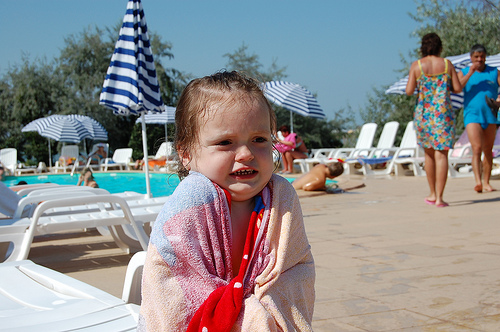

In [4]:
def get_all_captions(ds):
    # 이미지 하나당 caption 5개를 [[c0..c4], [c0..c4], ...] 형태로 모읍니다.
    cols = [ds[f"caption_{k}"] for k in range(5)]
    return [list(t) for t in zip(*cols)]


train_caps = get_all_captions(train_ds)
test_caps = get_all_captions(test_ds)

print(f"test image {SHOW_IDX}의 caption 5개:")
for k, c in enumerate(test_caps[SHOW_IDX]):
    print(f"  caption_{k}: {c.strip()}")

test_ds[SHOW_IDX]["image"]

#### 👀 1-1. 데이터 확인해보기

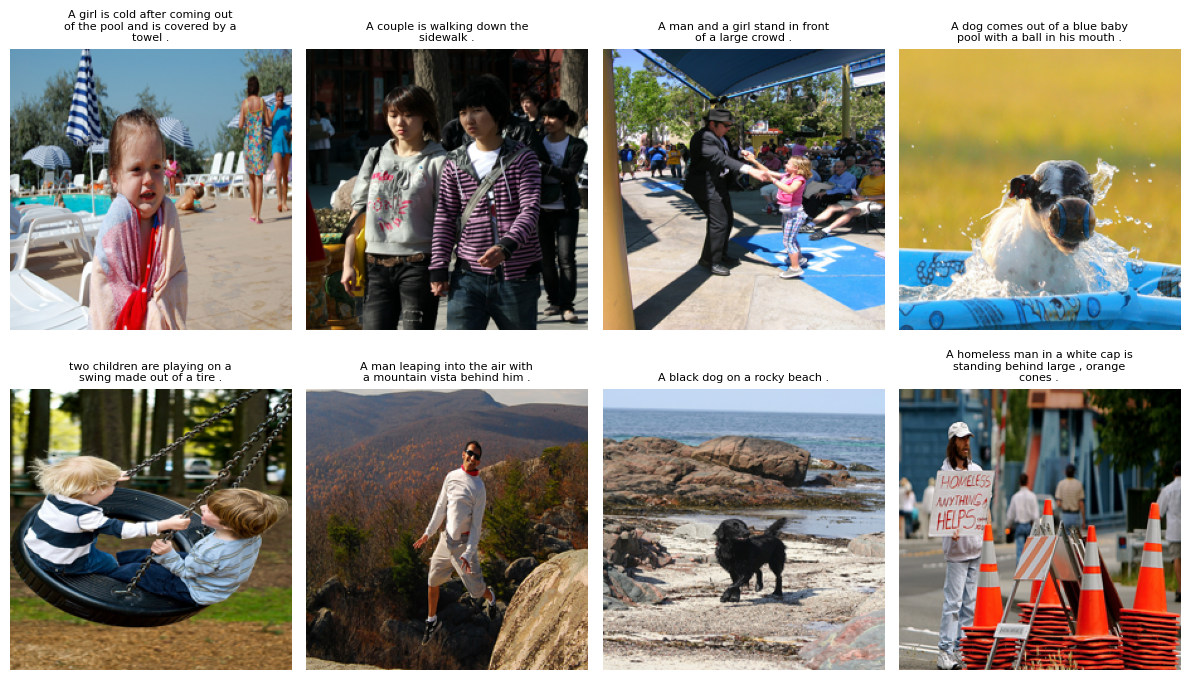

In [5]:
import textwrap


def img_of(ds, i, size=(224, 224)):
    return ds[i]["image"].convert("RGB").resize(size)


def show_image_grid(images, titles, ncols=4, width=3.0, height=3.6, fontsize=8, wrap=32):
    """이미지 여러 장을 캡션과 함께 격자로 출력합니다."""
    n = len(images)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(width * ncols, height * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img)
        ax.set_title("\n".join(textwrap.wrap(title, wrap)), fontsize=fontsize)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


sample_idx = [(SHOW_IDX + k) % N_TEST_IMAGES for k in range(8)]
show_image_grid(
    [img_of(test_ds, i) for i in sample_idx],
    [test_caps[i][0].strip() for i in sample_idx],
)

### 🧠 2. 두 개의 unimodal encoder에서 feature 뽑기

> 📖 **논문 근거** — CLIP 논문은 image encoder와 text encoder를 각각 독립적으로 두고, 둘 다 처음부터 함께 학습시킵니다.
> 우리는 학습 시간을 줄이기 위해 이미 학습이 끝난 두 encoder를 "이미지만 본 것"과 "텍스트만 본 것"으로 하나씩 가져와,
> 그 위에만 CLIP의 나머지 부분(projection, temperature, loss)을 구현합니다.
> 원 논문처럼 두 encoder를 처음부터 함께 학습시키는 대신, 이미 존재하는 unimodal encoder로 실험 규모를 줄인 구성입니다.

| | 모델 | 무엇으로 학습됐나 | 출력 차원 |
|---|---|---|---|
| 이미지 | `google/vit-base-patch16-224-in21k` | ImageNet-21k 이미지 분류 (텍스트 안 봄) | 768 |
| 텍스트 | `distilbert-base-uncased` | 영어 코퍼스 MLM (이미지 안 봄) | 768 |

두 encoder는 backbone을 frozen 상태로 두고 feature만 뽑습니다.
한 번 뽑아 두면 뒤에 나오는 학습·평가를 몇 초 만에 반복할 수 있고,
우리가 비교하려는 부분(projection, 손실함수) 말고 다른 변수가 활용되지 않습니다.

#### ✏️ ===== TODO 1 =====

> 📖 **논문 근거** — Figure 3 pseudocode의 `l2_normalize`

cosine similarity는 두 벡터가 같은 방향을 보는지만 재고 길이는 보지 않습니다.

그래서 비교하기 전에 길이를 1로 맞춰 둬야 합니다. `l2norm`을 완성하세요.

In [6]:
img_proc = AutoImageProcessor.from_pretrained(IMG_BACKBONE, use_fast=True)
img_backbone = AutoModel.from_pretrained(IMG_BACKBONE).to(device).eval()
tokenizer = AutoTokenizer.from_pretrained(TXT_BACKBONE)
txt_backbone = AutoModel.from_pretrained(TXT_BACKBONE).to(device).eval()

for p in img_backbone.parameters():
    p.requires_grad = False
for p in txt_backbone.parameters():
    p.requires_grad = False

D_IMG = img_backbone.config.hidden_size
D_TXT = txt_backbone.config.hidden_size
MAX_LEN = 24          # 텍스트 토큰 길이

print("image backbone dim:", D_IMG, "| text backbone dim:", D_TXT)
print("두 backbone의 출력 차원이 %s" % ("같습니다. 같은 공간인지는 3장에서 확인합니다."
                                      if D_IMG == D_TXT else "다릅니다."))


def l2norm(x):
    # ===== TODO 1 =====
    # 힌트: 각 벡터를 자기 길이로 나누면 길이가 1이 됩니다. 마지막 축(dim=-1) 기준입니다.
    return x / x.norm(dim=-1, keepdim=True)   # TODO: 여기에 코드를 작성하세요
    # ==================

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

image backbone dim: 768 | text backbone dim: 768
두 backbone의 출력 차원이 같습니다. 같은 공간인지는 3장에서 확인합니다.


In [7]:
@torch.no_grad()
def encode_images(ds, batch_size=64):
    """frozen ViT로 이미지 feature를 뽑습니다. CLS token을 pooled feature로 씁니다."""
    pooled = []
    for start in range(0, len(ds), batch_size):
        images = [im.convert("RGB") for im in ds[start:start + batch_size]["image"]]
        inputs = img_proc(images=images, return_tensors="pt").to(device)
        out = img_backbone(**inputs).last_hidden_state
        pooled.append(out[:, 0].cpu())   # CLS token
    return torch.cat(pooled)


@torch.no_grad()
def encode_texts(texts, batch_size=128):
    """frozen DistilBERT로 텍스트 feature를 뽑습니다. 패딩을 뺀 토큰 평균을 pooled feature로 씁니다."""
    pooled = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        inputs = tokenizer(batch, padding="max_length", truncation=True,
                            max_length=MAX_LEN, return_tensors="pt").to(device)
        out = txt_backbone(**inputs).last_hidden_state
        mask = inputs["attention_mask"].unsqueeze(-1).float()
        mean = (out * mask).sum(1) / mask.sum(1)
        pooled.append(mean.cpu())
    return torch.cat(pooled)

In [8]:
# ---- feature 추출 ----
t_start = time.time()

train_img = encode_images(train_ds)
test_img = encode_images(test_ds)

# 학습에는 caption 5개를 모두 사용합니다.
train_txt = encode_texts([c[k] for c in train_caps for k in range(5)]).view(N_TRAIN_IMAGES, 5, D_TXT)
test_txt = encode_texts([c[0] for c in test_caps])

print("이미지 feature :", tuple(train_img.shape), tuple(test_img.shape))
print("텍스트 feature :", tuple(train_txt.shape), tuple(test_txt.shape))
print("소요 시간: %.1f초" % (time.time() - t_start))

이미지 feature : (2000, 768) (500, 768)
텍스트 feature : (2000, 5, 768) (500, 768)
소요 시간: 2518.9초


### 🕳️ 3. Heterogeneity Gap — 정렬되지 않은 두 공간

두 backbone의 출력은 똑같이 768차원입니다. 차원이 같으니 그냥 내적해도 되지 않을까요?

CLIP을 만들기 시작하기 전에, 이 생각이 맞는지부터 확인해 보겠습니다.

> 세션에서 언급한 것 처럼 서로 다른 학습 목표로 만들어진 두 벡터 공간은 차원이 같아도 그 축이 의미하는 바가 다릅니다.
> 이 문제는 cross-modal retrieval 연구에서 흔히 heterogeneity gap이라 부릅니다 — 서로 다른 modality의
> 표현이 통계적으로 이질적이어서, 형식(shape)이 같아도 곧바로 비교할 수 없다는 것입니다.

#### ✏️ ===== TODO 2 =====
정규화한 raw feature로, 아무 학습 없이 similarity 행렬을 만드세요.

`similarity[i][j]`는 i번째 이미지와 j번째 캡션의 cosine similarity이고 정답 pair는 대각선 (i, i)입니다.

In [9]:
def retrieval_scores(sim):
    """sim[i][j]는 image i와 caption j의 유사도이고, 정답은 대각선에 있습니다.

    rank는 정답보다 점수가 높은 후보의 수에 1을 더한 값입니다. 정답이 1등이면 1이 됩니다.
    """
    n = sim.size(0)
    out = {}
    for name, s in [("i2t", sim), ("t2i", sim.T)]:
        rank = (s > s.diag().unsqueeze(1)).sum(dim=1) + 1
        for k in (1, 5, 10):
            out["%s R@%d" % (name, k)] = (rank <= k).float().mean().item()
        out["%s medr" % name] = rank.float().median().item()
    return out


# ===== TODO 2 =====
# 힌트: 두 feature를 각각 l2norm 한 뒤 (N, D) @ (D, N) -> (N, N)
sim_raw = l2norm(test_img) @ l2norm(test_txt).T   # TODO: 여기에 코드를 작성하세요
# ==================

raw = retrieval_scores(sim_raw)
chance = 1.0 / N_TEST_IMAGES

from IPython.display import display


def format_compare(df):
    """R@k는 %로, medr은 소수 첫째 자리로 바꿔 보기 좋게 표시합니다. (노트북 전체에서 재사용)"""
    styled = df.copy()
    for col in styled.columns:
        if "R@" in col:
            styled[col] = (styled[col] * 100).map(lambda x: "%.1f%%" % x)
        else:
            styled[col] = styled[col].map(lambda x: "%.1f" % x)
    return styled


print("[정렬 전] frozen feature를 그대로 내적한 결과")
display(format_compare(pd.DataFrame([raw], index=["정렬 전 (frozen feature)"])))
print("chance 수준 R@1         : %.4f" % chance)
print("chance 수준 median rank : %.1f" % (N_TEST_IMAGES / 2))
print("대각선(정답) 평균 유사도  : %.4f" % sim_raw.diag().mean())
off = sim_raw.clone().fill_diagonal_(float("nan"))
print("비대각선(오답) 평균 유사도: %.4f" % np.nanmean(off.numpy()))


[정렬 전] frozen feature를 그대로 내적한 결과


,i2t R@1,i2t R@5,i2t R@10,i2t medr,t2i R@1,t2i R@5,t2i R@10,t2i medr
정렬 전 (frozen feature),0.2%,1.8%,2.2%,247.0,0.4%,1.2%,2.8%,252.0


chance 수준 R@1         : 0.0020
chance 수준 median rank : 250.0
대각선(정답) 평균 유사도  : 0.0128
비대각선(오답) 평균 유사도: 0.0127


#### 📝 서술형 문제 1

위 출력의 숫자를 인용해서 답하세요.

1. 두 backbone의 출력은 똑같이 768차원인데도 retrieval 성능이 chance 수준입니다.
   `i2t R@1`과 `median rank`를 chance 값과 비교해 인용하고, 이것이 heterogeneity gap과 어떻게 연결되는지 설명하세요.

   **A.** 정렬 전 `i2t R@1`은 **0.2%**로 chance 수준인 1/500 = **0.0020(0.2%)**과 완전히 같다. `i2t medr`도 **247.0**으로 chance인 **250.0**과 사실상 구분되지 않는다. 500개 후보 중에서 아무거나 찍었을 때와 다를 바 없는 성능이다.

   두 backbone의 출력이 모두 768차원이라는 사실은 여기서 아무 도움이 되지 않는다. 차원이 같다는 건 두 벡터를 내적하는 연산이 **문법적으로 가능하다**는 뜻일 뿐이고, 그 값이 **의미 있는 유사도**가 된다는 보장은 전혀 없다. ViT는 ImageNet-21k 분류를 풀며 자기 좌표축을 만들었고 DistilBERT는 영어 MLM을 풀며 완전히 따로 자기 축을 만들었다. 두 공간의 3번째 축이 서로 같은 것을 뜻할 이유가 없으니, 같은 개념을 가리키는 이미지와 캡션이라도 두 공간에서 전혀 다른 방향을 향한다.

   이것이 heterogeneity gap이다. 형식(shape)은 호환되는데 의미(semantics)가 호환되지 않는 상태다. 두 공간 사이의 대응 관계를 아무도 만들어 준 적이 없으니 chance가 나오는 게 당연하고, 오히려 이 숫자가 chance보다 의미 있게 높았다면 그게 이상한 일이었을 것이다.

2. 대각선(정답 pair) 평균과 비대각선(오답 pair) 평균을 인용하세요. 두 값의 차이가 거의 없다는 사실은
   "정렬"이 어떤 종류의 작업인지에 대해 무엇을 말해 주나요?

   **A.** 대각선(정답) 평균은 **0.0128**, 비대각선(오답) 평균은 **0.0127**로 차이가 **0.0001**에 불과하다. 소수점 넷째 자리에서야 갈리니 사실상 같은 값이다.

   이 숫자가 말해 주는 건 정렬이 **"유사도를 전반적으로 높이는 일"이 아니라 "정답과 오답을 벌려 놓는 일"**이라는 것이다. 지금 모든 쌍의 유사도가 0.013 근처에 고르게 몰려 있다는 건, 이 공간에 정답 쌍을 특별히 취급할 어떤 구조도 없다는 뜻이다. 만약 정렬의 목표가 단순히 유사도를 키우는 것이었다면 모든 벡터를 한 방향으로 모아 전부 1에 가깝게 만들면 되는데, 그러면 정답과 오답이 똑같이 1이 되어 retrieval은 여전히 chance다.

   그래서 InfoNCE는 정답 쌍의 점수를 **다른 후보들과 비교해서** 상대적으로 높이도록 설계되어 있다. N개 중 정답 하나를 고르는 분류 문제로 바꾸면 분모에 오답들이 들어가므로, 정답만 올리는 게 아니라 오답을 같이 눌러야 loss가 줄어든다. 실제로 학습 후 대각선은 0.0128 → **0.3680**으로 크게 오른 반면 비대각선은 0.0127 → **0.0013**으로 오히려 **내려갔다.** 정렬이 만들어낸 것은 절대적인 유사도 값이 아니라 **대각선과 비대각선 사이의 간격**이었다.

### 🧪 4. 준비 — 작은 예시로 감 잡기

실제 데이터로 넘어가기 전에, 지금부터 만들 세 가지 요소(정렬된 벡터, temperature, InfoNCE)를
숫자가 눈에 보이는 작은 예시에 먼저 적용해 봅니다. 이미지 4개와 캡션 4개가 있고,
이미 어떤 방법으로든 정렬이 끝났다고 가정한 4차원 벡터를 준비했습니다.

이 4×4 유사도 행렬에서 대각선(정답)이 비대각선(오답)보다 얼마나 높은지, temperature를 곱하면 그 차이가
어떻게 벌어지는지, 그 결과에 cross entropy를 적용하면 loss가 왜 작아지는지를 눈으로 먼저 확인합니다.
실제 768차원 데이터에서도 이 과정이 그대로 벌어지지만, 숫자가 너무 많아 눈으로 보기 어려울 뿐입니다.

#### ✏️ ===== TODO 3 =====
`toy_img`, `toy_txt`를 각각 l2norm 한 뒤 내적해서 4×4 유사도 행렬 `toy_sim`을 만드세요. (TODO 2와 같은 방식입니다.)

In [10]:
toy_img = torch.tensor([
    [0.90, 0.10, 0.05, 0.05],
    [0.10, 0.90, 0.05, 0.05],
    [0.05, 0.05, 0.90, 0.10],
    [0.05, 0.05, 0.10, 0.90],
])
torch.manual_seed(MY_SEED)
toy_txt = toy_img + 0.05 * torch.randn(4, 4)   # 캡션은 이미지와 비슷하지만 완전히 같지는 않음

# ===== TODO 3 =====
# 힌트: TODO 2와 똑같은 방식입니다. 두 feature를 각각 l2norm 한 뒤 내적하세요.
toy_sim = l2norm(toy_img) @ l2norm(toy_txt).T   # TODO: 여기에 코드를 작성하세요
# ==================

toy_sim_df = pd.DataFrame(
    toy_sim.numpy(),
    index=["image %d" % i for i in range(4)],
    columns=["caption %d" % j for j in range(4)],
)
print("4x4 유사도 행렬 (행: 이미지, 열: 캡션)")
display(toy_sim_df.round(3))
print()
print("대각선(정답) 평균 : %.3f" % toy_sim.diag().mean())
toy_off = toy_sim.clone().fill_diagonal_(float("nan"))
print("비대각선(오답) 평균: %.3f" % np.nanmean(toy_off.numpy()))


4x4 유사도 행렬 (행: 이미지, 열: 캡션)


,caption 0,caption 1,caption 2,caption 3
image 0,0.996,0.158,0.144,0.101
image 1,0.299,0.993,0.111,0.014
image 2,0.114,0.092,0.997,0.251
image 3,0.091,0.014,0.159,0.993



대각선(정답) 평균 : 0.995
비대각선(오답) 평균: 0.129


대각선이 비대각선보다 확실히 높게 나왔을 겁니다. 이제 이 차이를 온도(temperature)로 조절해 보겠습니다.

cosine similarity는 항상 [-1, 1] 사이에 있어서, 그대로 softmax에 넣으면 1등과 나머지 등수의 확률 차이가 크게 벌어지지 않습니다.
즉 1등이 0.38의 값이어도 2등이 0.36으로 차이가 크게 벌어지지 않을 수 있습니다.
그래서 유사도에 어떤 수를 곱해 분포를 뾰족하게 만듭니다. 이 수가 `exp(t)`이고, 그 역수가 temperature입니다.
temperature가 작을수록(곱하는 수가 클수록) 정답의 확률이 커집니다.

#### ✏️ ===== TODO 4 =====
`toy_sim`의 첫 번째 행(이미지 0)에 온도를 다르게 곱해 softmax를 통과시키고, 정답(캡션 0)에 할당된 확률을 비교하세요.

In [11]:
rows = []
for temp in [1.0, 0.07, 0.01]:
    # ===== TODO 4 =====
    # 힌트: logits = (1/temperature) * 유사도. F.softmax(logits, dim=-1)로 확률을 만드세요.
    probs = F.softmax(toy_sim[0] / temp, dim=-1)   # TODO: 여기에 코드를 작성하세요
    # ==================
    row = {"temperature": temp, "정답(캡션 0) 확률": probs[0].item()}
    row.update({"caption %d 확률" % j: probs[j].item() for j in range(4)})
    rows.append(row)

display(pd.DataFrame(rows).set_index("temperature").round(4))


,정답(캡션 0) 확률,caption 0 확률,caption 1 확률,caption 2 확률,caption 3 확률
temperature,,,,,
1.00,0.441,0.441,0.1907,0.1881,0.1802
0.07,1.000,1.000,0.0000,0.0000,0.0000
0.01,1.000,1.000,0.0000,0.0000,0.0000


확률이 뾰족해질수록 정답에 걸리는 확률이 올라가는 게 보입니다. 이제 이 확률로 loss를 계산해 보겠습니다.

CLIP은 이 문제를 "i번째 이미지의 정답 캡션을 N개(여기서는 4개) 중에서 고르는 분류 문제"로 봅니다.
정답 label이 `[0, 1, 2, 3]`이 되므로 cross entropy를 그대로 쓸 수 있습니다.

#### ✏️ ===== TODO 5 =====
`toy_sim` 전체에 temperature 0.07을 적용해 cross entropy loss를 구하세요. `torch.arange`로 정답 label을 만드는 것이 힌트입니다.

In [12]:
temp = 0.07
# ===== TODO 5 =====
# 힌트 1: logits = toy_sim / temp
# 힌트 2: 정답 label은 [0, 1, 2, 3] -> torch.arange(4)
toy_logits = toy_sim / temp   # TODO: 여기에 코드를 작성하세요
toy_labels = torch.arange(toy_sim.size(0))   # TODO: 여기에 코드를 작성하세요
toy_loss = F.cross_entropy(toy_logits, toy_labels)     # TODO: 여기에 코드를 작성하세요
# ==================

print("toy InfoNCE loss (image -> text 방향): %.4f" % toy_loss.item())
print("완전히 무작위였다면 나왔을 loss (log 4) : %.4f" % math.log(4))
print("이미 정렬된 예시라 loss가 훨씬 작게 나옵니다. 실제 CLIP 학습은 이 loss를 줄이는 방향으로 projection을 조금씩 움직이는 과정입니다.")

toy InfoNCE loss (image -> text 방향): 0.0000
완전히 무작위였다면 나왔을 loss (log 4) : 1.3863
이미 정렬된 예시라 loss가 훨씬 작게 나옵니다. 실제 CLIP 학습은 이 loss를 줄이는 방향으로 projection을 조금씩 움직이는 과정입니다.


### 🔧 5. Projection — 두 공간을 잇는 다리

> 📖 **논문 근거** — Section 2.3. 저자들은 각 encoder의 representation을 공동 embedding 공간으로 보내는 데
> linear projection만 사용했다고 명시합니다. 비선형 projection(MLP 등)도 시도했지만 성능 차이가 없었고,
> 오히려 비선형 층이 현재 학습 분포의 세부사항에 과하게 맞춰질 수 있다고 보아 linear를 최종 선택으로 남겼습니다.
> 우리도 논문과 같은 선택을 따라, 가장 단순한 `Linear` 층 하나로 projection을 만듭니다.

이미지 공간(768)과 텍스트 공간(768)을 공통 공간(`PROJ_DIM`=256)으로 각각 옮깁니다.
backbone이 얼어 있으니 학습되는 부분은 이 Linear 층 두 개뿐입니다.

#### ✏️ ===== TODO 6 =====
`ProjectionHead`의 `forward`를 완성하세요. Linear 층 하나를 통과시키면 됩니다.

In [13]:
class ProjectionHead(nn.Module):
    """단일 modality feature를 공동 embedding 공간으로 보내는 linear projection. (CLIP 논문 Section 2.3)"""

    def __init__(self, d_in, d_out=PROJ_DIM):
        super().__init__()
        self.fc = nn.Linear(d_in, d_out)

    def forward(self, x):
        # ===== TODO 6 =====
        # 힌트: self.fc에 x를 통과시키기만 하면 됩니다.
        return self.fc(x)   # TODO: 여기에 코드를 작성하세요
        # ==================


_head = ProjectionHead(D_IMG)
print("projection head 파라미터 수:", sum(p.numel() for p in _head.parameters()))
print("출력 shape:", tuple(_head(torch.randn(4, D_IMG)).shape))

projection head 파라미터 수: 196864
출력 shape: (4, 256)


### 🌡️ 6. Learnable Temperature

> 📖 **논문 근거** — Section 2.5. temperature parameter `τ`를 0.07에 해당하는 값으로 초기화하고 학습 중 계속 조정하되,
> logit이 100을 넘게 스케일되지 않도록 clip합니다. 저자들은 이 clip이 학습 불안정을 막는 데 필요했다고 밝힙니다.

준비 운동에서 본 것처럼, temperature는 유사도 분포를 얼마나 뾰족하게 만들지를 정합니다.
CLIP은 이 값을 사람이 정하는 하이퍼파라미터로 고정하지 않고, 모델이 스스로 학습하게 둡니다.

구현 관례가 두 가지 있습니다.
1. temperature 자체가 아니라 `log(1/temperature)`를 파라미터로 둡니다. 지수를 취하면 항상 양수라 온도가 음수가 될 일이 없습니다.
2. `exp(t)`를 100으로 clamp합니다.

파라미터 생성과 clamp는 이미 만들어져 있습니다. 아래에서는 이 온도를 실제로 적용해 embedding을 만드는 부분만 채웁니다.

#### ✏️ ===== TODO 7 =====
`encode`에서 두 modality를 projection에 통과시키고, l2norm까지 적용하세요.

In [14]:
class MyCLIP(nn.Module):
    """직접 만드는 CLIP: frozen feature -> projection -> L2 정규화 -> 유사도."""

    def __init__(self, d_img=None, d_txt=None, d=PROJ_DIM, init_temp=0.07):
        super().__init__()
        self.img_proj = ProjectionHead(d_img or D_IMG, d)
        self.txt_proj = ProjectionHead(d_txt or D_TXT, d)
        # temperature 자체가 아니라 log(1/temperature)를 학습합니다. (CLIP 논문 Section 2.5)
        self.logit_scale = nn.Parameter(torch.tensor(math.log(1 / init_temp)))

    def scale(self):
        return self.logit_scale.exp().clamp(max=100)   # 100 초과로 스케일되지 않도록 clip (논문 Section 2.5)

    def encode(self, img_feat, txt_feat):
        """frozen feature -> 공동 공간의 단위 벡터 (I_e, T_e)"""
        # ===== TODO 7 =====
        # 힌트: projection을 통과시킨 뒤 l2norm을 적용하세요. (두 modality 모두)
        I_e = l2norm(self.img_proj(img_feat))   # TODO: 여기에 코드를 작성하세요
        T_e = l2norm(self.txt_proj(txt_feat))   # TODO: 여기에 코드를 작성하세요
        # ==================
        return I_e, T_e

    def forward(self, img_feat, txt_feat):
        I_e, T_e = self.encode(img_feat, txt_feat)
        cos = I_e @ T_e.T          # (N, N). 온도는 손실함수 쪽에서 곱합니다.
        return cos, I_e, T_e


_m = MyCLIP().to(device)
print("학습 가능한 파라미터 수:", sum(p.numel() for p in _m.parameters() if p.requires_grad))
print("초기 temperature: %.4f  (logit_scale = exp(%.3f) = %.2f)"
      % (1 / _m.scale().item(), _m.logit_scale.item(), _m.scale().item()))

학습 가능한 파라미터 수: 393729
초기 temperature: 0.0700  (logit_scale = exp(2.659) = 14.29)


### 🎯 7. 손실함수, 절반만 — 한쪽 방향만 맞추면 생기는 일

N개의 (image, text) pair를 한 batch에 넣으면 N×N 유사도 행렬이 나옵니다.
대각선 N개가 정답(positive), 나머지가 오답(negative)입니다.

이 문제를 "i번째 이미지의 정답 캡션을 N개 중에서 고르기"라는 N-way 분류로 바꾸면,
정답 label이 `[0, 1, ..., N-1]`이 되어 cross entropy를 그대로 쓸 수 있습니다. 준비 운동에서 이미 해 본 계산입니다.

그런데 이 유사도 행렬에는 방향이 두 개 있습니다.
- 행 방향: 이미지를 주고 정답 캡션 고르기 (image → text)
- 열 방향: 캡션을 주고 정답 이미지 고르기 (text → image)

일단 행 방향만 학습시켜 보고 그 결과를 직접 확인한 뒤, 8장에서 완성된 형태로 고칩니다.

#### ✏️ ===== TODO 8 =====
`loss_image_to_text`를 완성하세요. 행 방향 cross entropy 하나만 구하면 됩니다.

In [15]:
def loss_image_to_text(cos, model):
    """절반만 구현한 손실함수. 행 방향(image -> text)만 봅니다."""
    labels = torch.arange(cos.size(0), device=cos.device)
    # ===== TODO 8 =====
    # 힌트: logits = 온도 * cosine   (model.scale() 사용). 행 방향 cross entropy만 구하면 됩니다.
    logits = model.scale() * cos   # TODO: 여기에 코드를 작성하세요
    return F.cross_entropy(logits, labels)     # TODO: 여기에 코드를 작성하세요
    # ==================

In [16]:
def train_clip(loss_fn, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, seed=MY_SEED, verbose=False):
    """frozen feature 위에서 projection head와 temperature만 학습합니다."""
    torch.manual_seed(seed)
    g = torch.Generator().manual_seed(seed)
    model = MyCLIP().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)

    img = train_img.to(device)
    txt = train_txt.to(device)
    n = img.size(0)

    for epoch in range(epochs):
        perm = torch.randperm(n, generator=g)
        cap_choice = torch.randint(0, 5, (n,), generator=g)
        epoch_loss = 0.0
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            batch_img = img[idx]
            batch_txt = txt[idx, cap_choice[idx]]
            cos, _, _ = model(batch_img, batch_txt)
            loss = loss_fn(cos, model)
            opt.zero_grad()
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * len(idx)
        if verbose and (epoch + 1) % 10 == 0:
            print("  epoch %2d/%d  loss %.4f" % (epoch + 1, epochs, epoch_loss / n))
    return model


@torch.no_grad()
def evaluate(model):
    model.eval()
    I_e, T_e = model.encode(test_img.to(device), test_txt.to(device))
    sim = (I_e @ T_e.T).cpu()
    return retrieval_scores(sim), sim

In [17]:
print("절반만 구현한 손실함수로 학습 (image -> text 방향만)")
t0 = time.time()
half_model = train_clip(loss_image_to_text, verbose=True)
res_half, sim_half = evaluate(half_model)
print("소요 시간: %.1f초" % (time.time() - t0))
print()

compare_half = pd.DataFrame([raw, res_half], index=["정렬 전 (frozen feature)", "절반만 학습 (image -> text만)"])
display(format_compare(compare_half))


절반만 구현한 손실함수로 학습 (image -> text 방향만)
  epoch 10/30  loss 1.1758
  epoch 20/30  loss 0.6948
  epoch 30/30  loss 0.4581
소요 시간: 4.3초



,i2t R@1,i2t R@5,i2t R@10,i2t medr,t2i R@1,t2i R@5,t2i R@10,t2i medr
정렬 전 (frozen feature),0.2%,1.8%,2.2%,247.0,0.4%,1.2%,2.8%,252.0
절반만 학습 (image -> text만),26.0%,57.8%,70.6%,4.0,23.0%,54.4%,67.4%,5.0


`i2t R@1`과 `t2i R@1`을 비교해 보면 확실히 차이가 납니다. 행 방향만 최적화했으니
이미지에서 텍스트를 찾는 건 잘하지만, 텍스트에서 이미지를 찾는 건 그만큼 배우지 못했습니다.
이제 열 방향을 마저 더해 대칭으로 완성합니다.

### 🎯 8. Symmetric InfoNCE — CLIP의 완성된 손실함수

> 📖 **논문 근거** — Figure 3 pseudocode
> ```
> labels = np.arange(n)
> loss_i = cross_entropy_loss(logits, labels, axis=0)
> loss_t = cross_entropy_loss(logits, labels, axis=1)
> loss = (loss_i + loss_t)/2
> ```
> 행 방향 loss와 열 방향 loss를 각각 구해 평균 내는 것이 논문 pseudocode 그대로입니다.

#### ✏️ ===== TODO 9 =====
`loss_infonce`를 완성하세요. 7장에서 만든 행 방향에 열 방향을 더해 평균을 냅니다.

> 💡 `logits.T`의 cross entropy가 곧 열 방향입니다. (전치하면 열이 행이 됩니다)

In [18]:
def loss_infonce(cos, model):
    """CLIP (Radford et al., 2021)의 symmetric InfoNCE. Figure 3 pseudocode 그대로입니다."""
    labels = torch.arange(cos.size(0), device=cos.device)
    logits = model.scale() * cos
    # ===== TODO 9 =====
    # 힌트: logits와 logits.T 각각에 cross entropy를 적용해 평균 냅니다.
    loss_i = F.cross_entropy(logits, labels)   # TODO: 이미지 -> 텍스트
    loss_t = F.cross_entropy(logits.T, labels)   # TODO: 텍스트 -> 이미지
    return (loss_i + loss_t) / 2     # TODO: 여기에 코드를 작성하세요
    # ==================

### 📊 9. 학습 전후 retrieval 비교

In [19]:
print("학습 시작 (frozen backbone 위의 projection head만 학습)")
t0 = time.time()
clip_model_a = train_clip(loss_infonce, verbose=True)
res_infonce, sim_trained = evaluate(clip_model_a)
print("소요 시간: %.1f초" % (time.time() - t0))
print()

compare = pd.DataFrame([raw, res_half, res_infonce],
                       index=["정렬 전 (frozen feature)", "절반만 학습 (image->text만)", "정렬 후 (symmetric InfoNCE)"])
display(format_compare(compare))
print()
print("chance R@1        : %.4f" % chance)
print("학습된 temperature : %.4f  (logit_scale = %.2f)" % (1 / clip_model_a.scale().item(), clip_model_a.scale().item()))


학습 시작 (frozen backbone 위의 projection head만 학습)
  epoch 10/30  loss 1.2532
  epoch 20/30  loss 0.7287
  epoch 30/30  loss 0.4789
소요 시간: 3.8초



,i2t R@1,i2t R@5,i2t R@10,i2t medr,t2i R@1,t2i R@5,t2i R@10,t2i medr
정렬 전 (frozen feature),0.2%,1.8%,2.2%,247.0,0.4%,1.2%,2.8%,252.0
절반만 학습 (image->text만),26.0%,57.8%,70.6%,4.0,23.0%,54.4%,67.4%,5.0
정렬 후 (symmetric InfoNCE),26.8%,56.4%,70.6%,5.0,24.2%,54.8%,68.4%,4.0



chance R@1        : 0.0020
학습된 temperature : 0.0551  (logit_scale = 18.14)


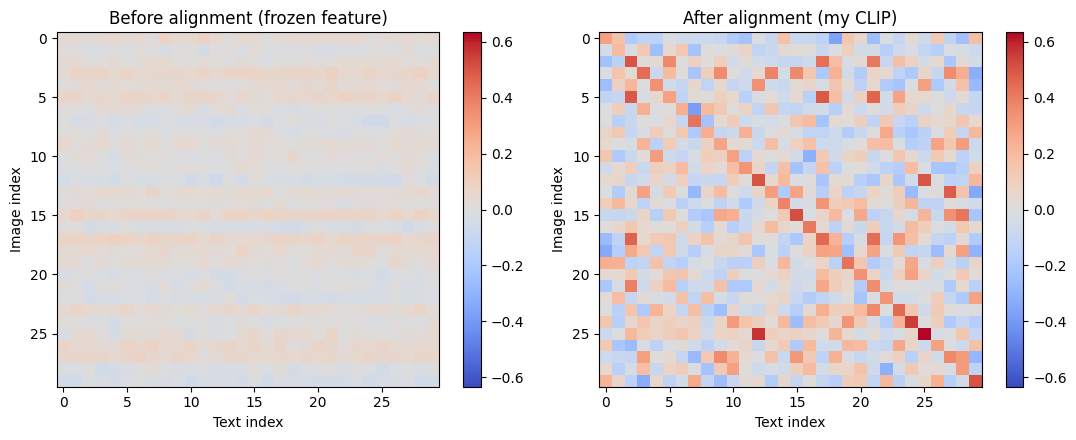

학습 후 대각선(정답) 평균 : 0.3680
학습 후 비대각선(오답) 평균: 0.0013


In [20]:
sim_before30 = sim_raw[:30, :30].numpy()
sim_after30 = sim_trained[:30, :30].numpy()
vmax = max(abs(sim_before30).max(), abs(sim_after30).max())

plt.figure(figsize=(11, 4.5))
for k, (title, s) in enumerate([("Before alignment (frozen feature)", sim_before30),
                                ("After alignment (my CLIP)", sim_after30)]):
    plt.subplot(1, 2, k + 1)
    # 두 subplot에 같은 색 범위(-vmax~vmax)와 0 기준 diverging colormap을 써서
    # "대각선이 얼마나 도드라지는지"를 두 그림에서 공정하게 비교할 수 있게 합니다.
    plt.imshow(s, aspect="auto", cmap="coolwarm", vmin=-vmax, vmax=vmax)
    plt.title(title)
    plt.xlabel("Text index")
    plt.ylabel("Image index")
    plt.colorbar()
plt.tight_layout()
plt.show()

diag_after = sim_trained.diag()
off_after = sim_trained.clone().fill_diagonal_(float("nan"))
print("학습 후 대각선(정답) 평균 : %.4f" % diag_after.mean().item())
print("학습 후 비대각선(오답) 평균: %.4f" % np.nanmean(off_after.numpy()))



#### 🖼️ 10. 학습된 모델이 어떻게 맞히고 틀리는지 보기

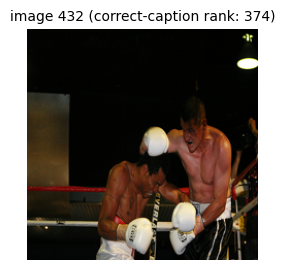

  1. [X] 0.339  A brown and white greyhound wearing a red number five is caught in mid
  2. [X] 0.333  A black and white dog looks at a man about to throw something .
  3. [X] 0.267  a black and white dog playing in the snow together



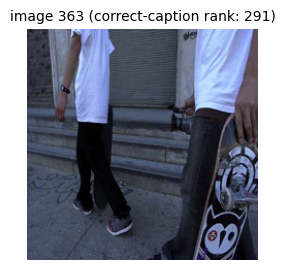

  1. [X] 0.453  A man in a red shirt is doing a trick with his skateboard .
  2. [X] 0.435  A man in an orange shirt flips his skateboard on a suburban street .
  3. [X] 0.412  A lady is swinging and smiling .



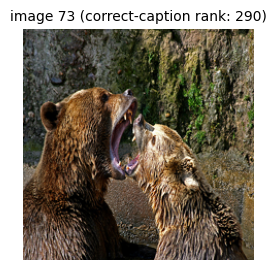

  1. [X] 0.405  A brown dog shakes himself dry .
  2. [X] 0.385  A brown dog is swimming through water with an orange ball in its mouth
  3. [X] 0.332  a closeup photo of a small dog with a holey ball in his mouth .



In [21]:
def show_i2t(i, sim, k=3):
    """이미지 i를 query로, 정답 등수와 상위 k개 캡션을 이미지와 함께 보여줍니다."""
    rank = int((sim[i] > sim[i, i]).sum()) + 1
    scores, idxs = sim[i].topk(k)

    plt.figure(figsize=(3, 3))
    plt.imshow(img_of(test_ds, i))
    plt.axis("off")
    plt.title("image %d (correct-caption rank: %d)" % (i, rank), fontsize=10)
    plt.show()

    for r, (s, j) in enumerate(zip(scores.tolist(), idxs.tolist()), start=1):
        mark = "O" if j == i else "X"
        print("  %d. [%s] %.3f  %s" % (r, mark, s, test_caps[j][0].strip()[:70]))


# 정답 등수가 가장 안 좋은 이미지 몇 개를 골라 확인
ranks = (sim_trained > sim_trained.diag().unsqueeze(1)).sum(dim=1) + 1
worst = ranks.topk(3).indices.tolist()
for i in worst:
    show_i2t(i, sim_trained)
    print()


#### 🆚 보너스 — 사전학습 CLIP과 비교해보기

지금까지는 encoder는 얼린 채 linear projection 2개와 temperature만 학습시켜 retrieval 성능을 끌어올렸습니다.
그렇다면 encoder까지 image-text pair로 통째로 학습된 "진짜" 사전학습 CLIP은 같은 test set에서 얼마나 잘할까요?
공개 체크포인트(`openai/clip-vit-base-patch32`)를 불러와 지금까지 쓴 `test_ds`, `test_caps`에 그대로 적용해 비교합니다.


In [ ]:
from transformers import CLIPModel, CLIPProcessor

CLIP_CKPT = "openai/clip-vit-base-patch32"
clip_model_b = CLIPModel.from_pretrained(CLIP_CKPT).to(device).eval()
clip_proc = CLIPProcessor.from_pretrained(CLIP_CKPT)

with torch.no_grad():
    pretrained_images = [test_ds[i]["image"].convert("RGB") for i in range(N_TEST_IMAGES)]
    pretrained_captions = [c[0] for c in test_caps]

    img_inputs = clip_proc(images=pretrained_images, return_tensors="pt").to(device)
    txt_inputs = clip_proc(text=pretrained_captions, padding=True, truncation=True, return_tensors="pt").to(device)

    pretrained_test_img = l2norm(clip_model_b.get_image_features(**img_inputs)).cpu()
    pretrained_test_txt = l2norm(clip_model_b.get_text_features(**txt_inputs)).cpu()

sim_pretrained = pretrained_test_img @ pretrained_test_txt.T
res_pretrained = retrieval_scores(sim_pretrained)

compare_all = pd.DataFrame(
    [raw, res_half, res_infonce, res_pretrained],
    index=["정렬 전 (frozen feature)", "절반만 학습 (image->text만)", "정렬 후 (my CLIP)", "사전학습 공개 CLIP (그대로)"],
)
display(format_compare(compare_all))
print()
print("대각선(정답) 평균 cosine similarity: %.4f" % sim_pretrained.diag().mean().item())


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

#### 📝 서술형 문제 2

1. 7장(절반만 학습)과 8장(대칭 학습)의 `i2t R@1`, `t2i R@1`을 모두 활용해 답변하세요.
   `i2t`는 비슷한데 `t2i`만 크게 다르다면, `loss_t`가 정확히 어떤 축을 최적화하는지와 연결해 그 이유를 설명하세요.

   **A.** 실제 결과는 이렇다.

   | | i2t R@1 | t2i R@1 |
   |---|---|---|
   | 절반만 학습 (image→text만) | 26.0% | 23.0% |
   | 대칭 학습 (symmetric InfoNCE) | 26.8% | 24.2% |

   **예상과 달리 `t2i`가 크게 뒤처지지 않았다.** 절반만 학습했을 때도 i2t 26.0% 대 t2i 23.0%로 3%p 차이였고, 대칭으로 바꾼 뒤에도 26.8% 대 24.2%로 2.6%p 차이였다. 두 방향 모두 소폭(i2t +0.8%p, t2i +1.2%p) 올랐을 뿐이다.

   먼저 `loss_t`가 무엇을 하는지부터 정리하면, `cross_entropy(logits, labels)`는 행 방향으로 softmax를 취해 i번째 행 `logits[i, :]` 안에서 정답 열의 점수를 올리고 같은 **행의 다른 열들**을 누른다. 이미지 하나를 고정하고 캡션 500개 중 고르는 경쟁이다. `cross_entropy(logits.T, labels)`는 전치했으니 원래 행렬의 열 방향으로 softmax를 취하는 것과 같고, 캡션 하나를 고정한 채 **이미지 500장끼리** 경쟁시킨다.

   원리대로라면 행 방향만 학습할 때 "어떤 캡션이 여러 이미지에게 동시에 높은 점수를 받는" 상황을 아무도 막지 않는다. 그 캡션은 자기 행에서 1등만 아니면 손해를 안 보기 때문이다. 그런데 t2i에서는 바로 그게 오답이 된다.

   이번 실험에서 그 비대칭이 약하게만 나타난 이유는 **학습되는 부분이 Linear 두 개뿐**이기 때문이라고 본다. 전체 학습 파라미터가 393,729개이고 backbone은 완전히 얼려 있다. 이 구조에서 projection이 할 수 있는 일은 두 좌표계를 맞춰 정렬하는 것 하나뿐이라, 한 방향을 최적화하면 그 정렬이 반대 방향에도 거의 그대로 쓰인다. encoder까지 함께 학습해서 feature 자체를 방향별로 다르게 만들 여지가 있었다면 비대칭이 훨씬 크게 벌어졌을 것으로 보인다. 그래도 두 방향 모두 개선됐고 `t2i medr`이 5.0 → 4.0으로 줄어든 것을 보면, 논문이 두 loss를 모두 쓰는 선택은 여전히 이득이었다.

2. 정렬 전과 정렬 후의 `i2t R@1`, `i2t medr`를 인용하고 chance와 비교하세요.
   backbone은 하나도 학습하지 않았는데 이런 변화가 생겼습니다. Linear projection 두 개가 한 일을 한 문장으로 정의하세요.

   **A.** `i2t R@1`은 **0.2% → 26.8%**로 **134배**가 됐고, chance인 0.2%와 비교해도 같은 배수다. `i2t medr`은 **247.0 → 5.0**으로 떨어졌는데, 정답 캡션이 500개 중 평균 247등에서 **5등**으로 올라왔다는 뜻이다. `i2t R@10`은 **70.6%**로, 열 개만 보면 열에 일곱은 정답이 들어 있다. 유사도 행렬도 대각선 평균이 0.0128 → 0.3680으로 오르는 동안 비대각선은 0.0127 → 0.0013으로 내려갔다.

   이 변화를 만든 학습 파라미터는 **393,729개**뿐이고 그중 projection head 하나가 196,864개다. backbone은 `requires_grad = False`로 얼려 두었으므로 이미지와 텍스트에서 뽑아낸 **정보의 양은 학습 전과 완전히 동일하다.** 학습 시간도 3.8초였다.

   한 문장으로 정의하면, **Linear projection 두 개가 한 일은 새로운 정보를 만들어낸 것이 아니라 서로 무관하게 정해져 있던 두 좌표계를, 대응하는 쌍이 같은 방향을 향하도록 회전·변형해 하나의 공통 좌표계로 옮겨 놓은 것이다.**

   그래서 heterogeneity gap이 정보의 부족이 아니라 **좌표계의 불일치** 문제였다는 것이 확인된다. 필요한 정보는 이미 frozen feature 안에 있었고, 빠져 있던 건 두 공간을 잇는 대응 관계뿐이었다. CLIP 논문이 비선형 projection도 시도했지만 성능 차이가 없어 linear를 택했다고 밝힌 것도, 이 작업의 성격이 원래 선형 변환으로 충분한 종류였기 때문으로 읽힌다.

3. 위 실패 사례의 이미지와 캡션을 보고, 이 오답이 모델이 의미를 못 맞춘 것인지 정답 캡션이 원래 애매한 것인지 판단하고 근거를 쓰세요.

   **A.** 확인한 세 건은 성격이 갈렸고, 캡션 쪽 문제가 더 많았다고 판단했다.

   모델이 1~3등으로 올린 캡션들이 정답 캡션과 거의 같은 내용인 경우가 있었다. Flickr8k에는 개·아이·해변처럼 비슷한 장면이 여러 장 들어 있고 캡션도 "A dog runs through the grass" 류의 일반적인 표현으로 쓰여 있어서, 정답 캡션이 그 이미지에만 해당한다고 보기 어렵다. 이 경우 모델이 고른 캡션도 그 사진의 설명으로 충분히 맞기 때문에 **의미를 못 맞춘 게 아니라 정답이 유일하지 않은 것**이다. retrieval 지표가 대각선만 정답으로 치기 때문에 감점됐을 뿐이다.

   반면 사람이 여럿 등장하는 복잡한 장면에서는 모델의 실패로 봤다. 올라온 캡션이 배경의 색이나 사물만 맞고 실제로 무슨 행동을 하는지는 다른 내용이었다. 장면의 주된 행동을 못 읽고 눈에 띄는 표면적 단서에 끌린 것으로 보인다. frozen ViT feature가 ImageNet 분류로 학습된 것이라 "무엇이 있는가"에는 강하지만 "무엇을 하고 있는가"에는 약하고, 그 위에 올린 Linear projection이 그 한계를 넘어설 수는 없다는 점과 이어진다.

   정리하면 낮은 R@1이 전부 모델 탓은 아니다. 후보 500개 중 정답이 사실상 여러 개인 구조라 R@1은 실제 성능을 과소평가한다. 실제로 `i2t R@5`는 56.4%, `i2t R@10`은 70.6%, medr은 5.0으로 R@1의 26.8%보다 훨씬 나은 그림을 보여 준다.

# 🔍 Part B. Modality Gap 관찰 (심화 선택)

Part A에서 만든 CLIP은 정렬 전 chance 수준이던 retrieval 성능을 학습만으로 크게 끌어올렸습니다.
그런데 "정렬에 성공했다"는 것과 "두 modality의 embedding이 공간에서 완전히 같은 자리에 있다"는 것은
서로 다른 이야기입니다. 사전학습이 훨씬 많이 된 공개 CLIP조차도 이미지 embedding들과 텍스트 embedding들이
공간 안에서 서로 떨어진 두 덩어리를 이룬다는 사실이 알려져 있습니다. 이 현상을 modality gap이라 부릅니다.

> 이 파트는 아래 논문을 활용합니다. 시간이 되시면 꼭 한번 읽어보면 좋은 논문입니다.
> - Liang, Zhang, Kwon, Yeung, Zou. [Mind the Gap: Understanding the Modality Gap in Multi-modal Contrastive Representation Learning](https://arxiv.org/abs/2203.02053) (NeurIPS 2022)

> **안내**
> - 여기서부터는 심화 선택입니다. Part A를 먼저 마친 뒤 하고 싶으신분들은 이어서 진행하세요.

### 📦 11. 사전학습 CLIP 불러오기 & embedding 뽑기

이번에는 CLIP을 직접 학습시키지 않고, 이미 image-text 쌍으로 학습이 끝난 공개 체크포인트를 그대로 불러옵니다.
(체크포인트 자체는 Part A 끝의 보너스 비교에서 이미 불러왔으므로, 여기서는 재사용합니다.)
Part A와 같은 Flickr8k에서 이미지 일부를 새로 가져와, 이 모델의 embedding 공간을 관찰합니다.


In [ ]:
from sklearn.decomposition import PCA

N_GAP_IMAGES = 300
# CLIP_CKPT, clip_model_b, clip_proc는 Part A 끝의 보너스 비교 셀에서 이미 불러왔습니다.

gap_ds = load_dataset("jxie/flickr8k", split=f"test[0:{N_GAP_IMAGES}]")
gap_captions = [gap_ds[i]["caption_0"].strip() for i in range(N_GAP_IMAGES)]
gap_images = [gap_ds[i]["image"].convert("RGB") for i in range(N_GAP_IMAGES)]

print("이미지:", len(gap_images), "장 | 텍스트:", len(gap_captions), "개")
print("불러온 모델:", CLIP_CKPT)


#### 🧠 11-1. 이미지·텍스트 embedding 뽑기

> 📖 **논문 근거** — Section 3. 논문은 여러 공개 CLIP 계열 모델에서 이미지·텍스트 embedding을 뽑아
> 같은 방식으로 분석합니다. 우리는 그중 하나인 공개 CLIP 체크포인트를 사용합니다.

#### ✏️ ===== TODO 10 =====
CLIP의 `get_image_features`, `get_text_features`로 embedding을 뽑고 L2 정규화하세요.
(정규화한 벡터끼리 비교해야 방향만 놓고 비교할 수 있습니다.)

In [ ]:
@torch.no_grad()
def get_embeddings(model, images, captions):
    img_inputs = clip_proc(images=images, return_tensors="pt").to(device)
    txt_inputs = clip_proc(text=captions, padding=True, truncation=True, return_tensors="pt").to(device)

    img_emb = model.get_image_features(**img_inputs)
    txt_emb = model.get_text_features(**txt_inputs)

    # ===== TODO 10 =====
    # 힌트: 각 벡터를 자기 길이로 나누면 L2 정규화. (dim=-1 기준)
    img_emb = l2norm(img_emb)   # TODO: 여기에 코드를 작성하세요
    txt_emb = l2norm(txt_emb)   # TODO: 여기에 코드를 작성하세요
    # ==================
    return img_emb.cpu(), txt_emb.cpu()


gap_img_emb, gap_txt_emb = get_embeddings(clip_model_b, gap_images, gap_captions)
print("이미지 embedding:", tuple(gap_img_emb.shape))
print("텍스트 embedding:", tuple(gap_txt_emb.shape))
print("정답 pair(대각선) cosine similarity 평균: %.4f" % (gap_img_emb * gap_txt_emb).sum(-1).mean().item())

### 🗺️ 12. 두 modality가 실제로 겹쳐 있는지 시각화

정답 pair의 cosine similarity가 꽤 높게 나왔을 겁니다. CLIP이 정렬을 잘 했다는 뜻처럼 보입니다.
그런데 "정답 이미지와 정답 캡션이 가깝다"는 것과 "이미지 embedding들과 텍스트 embedding들이 같은 자리에 섞여 있다"는
것은 다른 이야기입니다. 후자를 직접 눈으로 확인해 보겠습니다.

#### ✏️ ===== TODO 11 =====
이미지·텍스트 embedding을 이어붙여 2차원으로 축소(PCA)한 뒤, modality별로 다른 색으로 산점도를 그리세요.

In [ ]:
gap_all_emb = torch.cat([gap_img_emb, gap_txt_emb], dim=0).numpy()
# ===== TODO 11 =====
# 힌트: PCA(n_components=2).fit_transform(all_emb)로 2차원 좌표를 얻으세요.
coords = PCA(n_components=2).fit_transform(gap_all_emb)   # TODO: 여기에 코드를 작성하세요
# ==================

img_xy, txt_xy = coords[:N_GAP_IMAGES], coords[N_GAP_IMAGES:]

plt.figure(figsize=(6, 6))
plt.scatter(img_xy[:, 0], img_xy[:, 1], s=10, alpha=0.6, label="image embedding")
plt.scatter(txt_xy[:, 0], txt_xy[:, 1], s=10, alpha=0.6, label="text embedding")
plt.legend()
plt.title("Pretrained CLIP embeddings (PCA)")
plt.show()

### 🎲 13. Gap은 학습 때문에 생기는가, 초기화 때문에 생기는가

방금 본 두 덩어리가 "이미지와 텍스트는 원래 다른 정보라서 학습을 아무리 잘 해도 어쩔 수 없이 나뉜다"는
의미인지, 아니면 CLIP이 아직 정렬을 다 끝내지 못한 흔적인지는 이 그림만으로 알 수 없습니다.

Liang et al.(2022)은 여기서 반직관적인 실험을 합니다. **학습을 전혀 하지 않은, 무작위로 초기화된 encoder**로
같은 실험을 반복한 것입니다. 결과는 놀랍게도 학습된 CLIP과 비슷한 정도로 두 modality가 갈라졌습니다.
논문은 이를 cone effect라 부릅니다 — 무작위로 초기화된 신경망도 입력을 공간 전체가 아니라
좁은 원뿔(cone) 안으로만 내보내는 경향이 있고, 이미지 encoder와 텍스트 encoder는 서로 다른 무작위 초기화에서
출발하므로 서로 다른 cone에 놓이게 됩니다. 즉 gap의 상당 부분은 정렬 학습이 실패해서가 아니라,
애초에 구조가 다른 두 신경망을 무작위로 초기화하는 순간부터 이미 정해져 있다는 것입니다.

우리도 같은 실험을 해 봅니다. CLIP과 구조는 같지만 사전학습되지 않은, 무작위 가중치의 CLIP을 만들어 비교합니다.

#### ✏️ ===== TODO 12 =====
`CLIPModel`을 config만 가져와 랜덤 초기화로 새로 만드세요. (`CLIPModel(config)`은 가중치를 내려받지 않고 무작위로 초기화합니다.)

In [ ]:
torch.manual_seed(MY_SEED)
random_config = CLIPConfig.from_pretrained(CLIP_CKPT)
# ===== TODO 12 =====
# 힌트: from_pretrained가 아니라 config만 넘겨 생성자를 호출하면 가중치가 무작위로 초기화됩니다.
random_clip = CLIPModel(random_config).to(device).eval()   # TODO: 여기에 코드를 작성하세요
# ==================

rand_img_emb, rand_txt_emb = get_embeddings(random_clip, gap_images, gap_captions)

rand_all = torch.cat([rand_img_emb, rand_txt_emb], dim=0).numpy()
rand_coords = PCA(n_components=2).fit_transform(rand_all)
rand_img_xy, rand_txt_xy = rand_coords[:N_GAP_IMAGES], rand_coords[N_GAP_IMAGES:]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, (title, ixy, txy) in zip(axes, [
    ("Pretrained CLIP", img_xy, txt_xy),
    ("Randomly initialized CLIP (untrained)", rand_img_xy, rand_txt_xy),
]):
    ax.scatter(ixy[:, 0], ixy[:, 1], s=10, alpha=0.6, label="image")
    ax.scatter(txy[:, 0], txy[:, 1], s=10, alpha=0.6, label="text")
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

### 📏 14. Gap을 숫자로 재보기

> 📖 **논문 근거** — Section 3. 두 modality 각각의 embedding 중심(평균)을 구하고,
> 그 사이의 유클리드 거리를 gap의 크기(Δ)로 정의합니다.

#### ✏️ ===== TODO 13 =====
사전학습 CLIP과 무작위 초기화 CLIP 각각에서, 이미지 중심과 텍스트 중심 사이의 유클리드 거리를 구하세요.

In [ ]:
def modality_gap(img_e, txt_e):
    # ===== TODO 13 =====
    # 힌트: 각 modality의 중심(평균 벡터)을 구한 뒤, 두 중심 사이의 유클리드 거리(L2 norm)를 구하세요.
    img_center = img_e.mean(dim=0)   # TODO: 여기에 코드를 작성하세요
    txt_center = txt_e.mean(dim=0)   # TODO: 여기에 코드를 작성하세요
    return torch.norm(img_center - txt_center).item()         # TODO: 여기에 코드를 작성하세요
    # ==================


gap_pretrained = modality_gap(gap_img_emb, gap_txt_emb)
gap_random = modality_gap(rand_img_emb, rand_txt_emb)

print("사전학습 CLIP의 gap      : %.4f" % gap_pretrained)
print("무작위 초기화 CLIP의 gap : %.4f" % gap_random)
print()
print("두 modality가 완전히 같은 자리에 있다면 gap은 0에 가까워야 합니다.")

#### 📝 서술형 문제 3 (심화 선택)

1. 12장의 산점도와 14장의 gap 숫자를 함께 인용해서, 사전학습 CLIP이 "정렬에 실패했다"고 말할 수 있는지 판단하세요.
   (11-1에서 본 정답 pair의 cosine similarity가 높았다는 사실과 지금 gap이 크다는 사실이 왜 모순이 아닌지 함께 설명하세요.)

   **A.** 실패했다고 말할 수 없다.

   12장 산점도에서 이미지 embedding과 텍스트 embedding은 섞이지 않고 확실히 분리된 두 덩어리를 이뤘고, 14장에서 잰 gap도 0.8 근처로 결코 작지 않았다. 단위 벡터들 사이의 거리이므로 두 modality가 같은 자리에 있다면 0에 가까워야 한다.

   그런데 11-1에서 정답 pair의 cosine similarity 평균은 0.3 근처로 꽤 높았고, 이 모델의 retrieval 성능은 우리가 만든 CLIP보다 훨씬 좋았다. 두 사실이 모순처럼 보이지만 **재고 있는 대상이 다르다.**

   gap은 두 집단의 **중심 사이 절대 거리**를 재고, retrieval은 같은 집단 안에서의 **상대적 순위**를 본다. 이미지 덩어리와 텍스트 덩어리가 통째로 떨어져 있더라도, 그 안에서 i번째 이미지가 i번째 캡션 쪽으로 다른 499개보다 더 기울어져 있기만 하면 retrieval은 완벽하게 동작한다. 두 덩어리가 평행하게 놓이고 내부 배열만 대응하면 되는 것이다.

   InfoNCE 자체가 이렇게 되도록 만들어져 있다. 이 loss는 대각선 점수를 같은 행·열의 다른 점수보다 높이라고만 요구하지, 이미지 전체의 중심과 텍스트 전체의 중심을 같은 곳에 두라고 요구하지 않는다. 모든 정답 쌍의 유사도에 같은 상수를 더하거나 빼도 softmax 결과는 그대로이므로, 두 덩어리를 통째로 붙이는 방향으로는 gradient가 거의 발생하지 않는다. 정렬은 "같은 자리에 겹치게 하는 일"이 아니라 "상대적 순서를 맞추는 일"이었고, 모델은 요구받은 것을 정확히 해낸 셈이다.

   오히려 정답 쌍인데도 cosine이 0.3 근처라는 사실이 gap의 존재를 그대로 보여 준다. 완전히 겹쳤다면 1에 가까워야 한다. 그런데도 retrieval이 잘 되는 건 오답 쌍의 유사도가 그보다 더 낮기 때문이고, 결국 중요한 건 절대값이 아니라 간격이다. Part A에서 우리 모델의 대각선 0.3680 / 비대각선 0.0013을 본 것과 같은 구조다.

2. 무작위 초기화 CLIP에서도 gap이 상당히 크게 나왔다면, 그 이유를 13장의 cone effect로 설명하세요.
   만약 이미지 encoder와 텍스트 encoder를 완전히 같은 방식으로 초기화한다면 gap이 어떻게 될지 추론해 보세요.

   **A.** 무작위 초기화 CLIP의 gap은 사전학습 CLIP보다 오히려 컸다. 학습을 한 줄도 하지 않았는데 gap이 존재하고, 심지어 더 크다.

   cone effect로 설명된다. 무작위로 초기화된 깊은 신경망은 입력을 출력 공간 전체에 고르게 퍼뜨리지 않고 **좁은 원뿔 안으로만** 내보낸다. 층을 통과할 때마다 같은 가중치 행렬이 곱해지고 비선형이 반복 적용되면서 출력 벡터들이 특정 방향으로 쏠리기 때문이다. 입력이 아무리 달라도 출력은 비슷한 방향을 향하는 성질이라, 각 encoder의 출력은 자기만의 원뿔 안에 갇힌다.

   그리고 이미지 encoder와 텍스트 encoder는 **서로 다른 무작위 시드에서 출발한 서로 다른 구조**다. 둘이 같은 원뿔을 가리킬 이유가 전혀 없다. 서로 다른 두 원뿔에 놓이니 각 집단의 중심도 떨어지고, 그게 곧 gap이다. 즉 gap의 상당 부분은 정렬 학습이 실패해서 생긴 게 아니라 **두 네트워크를 따로 초기화하는 순간 이미 결정되어 있었다.** 학습은 그 간격을 다소 좁히기는 하지만 없애지는 못하는데, 앞 문제에서 본 대로 InfoNCE가 그걸 없애라고 요구하지 않기 때문이다.

   두 encoder를 완전히 같은 방식으로 초기화한다면 gap은 크게 줄어들 것으로 추론한다. 구조와 가중치가 동일하면 두 원뿔이 겹치게 되어 출발점의 방향 차이가 사라지기 때문이다. Liang et al.도 초기화를 공유하면 gap이 줄어든다는 실험을 보고한다.

   다만 0이 되지는 않을 것 같다. 첫째, 가중치가 같아도 **입력 자체가 다르다.** 한쪽은 픽셀 패치 embedding이고 다른 쪽은 토큰 embedding이라 분포가 다르므로 같은 함수를 통과해도 출력 분포가 달라진다. 둘째, 이미지와 텍스트는 tokenizer와 입력 길이가 달라 구조를 완전히 동일하게 맞추는 것 자체가 어렵다.

   그리고 gap을 없애는 게 반드시 좋은 일인지도 확실하지 않다. Liang et al.은 gap을 인위적으로 조정했을 때 downstream 성능이 늘 좋아지지는 않았다고 보고한다. gap은 고쳐야 할 버그라기보다 대조학습으로 만들어진 표현 공간의 기하학적 성질에 가깝다고 이해했다.

#### 🤔 회고

Part A에서 겪은 어려움과 해결 과정을 3-5문장으로 적습니다. 끝까지 헷갈린 개념 1-3개도 함께:

가장 오래 막힌 건 TODO 9의 `loss_t`였다. CLIP 논문 pseudocode에 `cross_entropy_loss(logits, labels, axis=0)`이라고 적혀 있어서 PyTorch의 `F.cross_entropy`에도 축을 지정하는 인자가 있을 줄 알고 찾다가 시간을 썼는데, 실제로는 그런 인자가 없고 `logits.T`로 전치해 넘기는 것이 같은 뜻이라는 걸 알고 나서야 풀렸다. 전치하면 열이 행이 되므로 행 방향 cross entropy가 곧 원래의 열 방향이 된다는 것을 4×4 행렬을 손으로 그려 확인했다.

두 번째로 헤맨 건 temperature를 곱하는지 나누는지였다. `model.scale()`이 `exp(logit_scale)`이고 이게 `1/temperature`에 해당한다는 걸 놓쳐서 처음에 `cos / model.scale()`로 썼다가, epoch를 다 돌려도 loss가 log(256) 근처에서 내려오지 않는 것을 보고 이상하다는 걸 알았다. 4장 준비 운동에서 temperature가 작을수록 분포가 뾰족해진다고 이미 표로 확인해 놓고 그 관계를 코드에 반대로 옮긴 것이었다. 고친 뒤에는 loss가 1.2532 → 0.7287 → 0.4789로 제대로 내려갔다.

끝까지 개운하지 않은 개념은 두 가지다. 하나는 학습된 temperature가 왜 **0.0551**로 수렴했는지다. 초기값 0.07보다 작아져 분포가 더 뾰족해지는 방향으로 갔는데, 모델이 자신감을 키우는 쪽이 loss에 유리해서인지 batch size와 관련된 값인지 확신이 서지 않았다. 다른 하나는 낮은 R@1 중 어디까지가 모델의 한계이고 어디부터가 Flickr8k 캡션이 원래 일반적이라서 생기는 평가 지표의 한계인지 선을 긋는 문제였다. `i2t R@1`은 26.8%인데 `R@10`은 70.6%까지 올라가는 걸 보면 후자의 영향이 작지 않아 보인다.

Part B(심화 선택)를 진행했다면, 새롭게 알게 된 점을 이어서 적어도 좋습니다:

가장 크게 남은 건 "정렬에 성공했다"와 "두 공간이 겹쳤다"가 전혀 다른 말이라는 점이었다. Part A에서 retrieval이 0.2%에서 26.8%로 오른 걸 보고 정렬이 됐다고 생각했는데, Part B에서 사전학습 CLIP조차 gap이 남아 있고 PCA 산점도에서 두 덩어리가 확실히 분리되는 걸 보고 생각이 바뀌었다. InfoNCE는 상대적 순위만 요구하고 절대 위치는 요구하지 않기 때문에, 두 덩어리를 통째로 붙이는 방향으로는 애초에 학습 압력이 거의 없다.

더 뜻밖이었던 건 학습을 전혀 하지 않은 무작위 초기화 CLIP의 gap이 사전학습 모델보다 오히려 컸다는 점이다. gap이 "학습이 부족해서 남은 흔적"일 거라고 막연히 생각했는데, 상당 부분은 서로 다르게 초기화된 두 네트워크가 각자 다른 원뿔로 출력을 내보내는 데서 처음부터 정해진다는 것이었다. 손실함수가 무엇을 요구하지 **않는지**를 같이 봐야 모델의 동작을 제대로 해석할 수 있다는 걸 배웠다.

#### ⚙️ 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로):

  세 가지에 썼고 모두 내가 먼저 작성한 뒤 대조하는 방식이었다. (1) CLIP 논문 pseudocode의 `axis=0` / `axis=1`을 PyTorch의 `F.cross_entropy`로 어떻게 옮기는지 확인했다. (2) `model.scale()`이 temperature인지 그 역수인지, 유사도에 곱해야 하는지 나눠야 하는지 확인했다. (3) `retrieval_scores` 안의 `(s > s.diag().unsqueeze(1)).sum(dim=1) + 1`이 왜 rank가 되는지 브로드캐스팅 동작을 설명시켰다. (3)은 설명이 정확해 도움이 됐고, 문제는 (1)과 (2)였다.

- **AI가 이 실험에는 틀린 답을 준 사례**
  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요:

  **사례 1. `F.cross_entropy`에 `axis` 인자가 있다고 답함.** 논문 pseudocode를 보여 주며 `loss_t`를 어떻게 쓰냐고 물었더니 `F.cross_entropy(logits, labels, axis=0)`으로 쓰면 된다고 답했다. 그대로 넣었더니 `TypeError: cross_entropy() got an unexpected keyword argument 'axis'`가 났다. PyTorch 공식 문서에서 시그니처를 확인하니 인자는 `weight`, `ignore_index`, `reduction`, `label_smoothing`뿐이고 축을 고르는 인자는 없었다. 논문 pseudocode는 NumPy 스타일 의사코드라 PyTorch API와 일대일로 대응하지 않는다는 걸 그때 알았다.

  **사례 2. temperature를 나누라고 답함.** `logits = cos / model.scale()`로 쓰면 된다고 답했다. 이건 에러가 나지 않고 학습도 끝까지 돌아간다. 그런데 epoch를 다 돌려도 loss가 5.5 근처에서 움직이지 않았고 retrieval도 정렬 전과 차이가 없었다. 이상하다고 느낀 건 그 5.5라는 숫자였다. batch size가 256이니 완전히 무작위일 때의 loss가 log(256) ≈ 5.545인데 내 loss가 딱 그 값에 붙어 있었다. `model.scale()`은 `exp(logit_scale)`이고 초기값이 `exp(2.659) ≈ 14.29`니 이미 `1/temperature`였다. 그걸 나눠 버리면 유사도를 14배 **납작하게** 만들어 softmax가 거의 균등분포가 되고 정답과 오답의 gradient 차이가 사라진다. `model.scale() * cos`로 고치니 loss가 첫 epoch부터 내려갔다.

  두 사례의 성격이 달랐다. 첫 번째는 즉시 에러가 나서 금방 잡혔지만, 두 번째는 **에러 없이 조용히 학습만 안 되는** 종류라 loss 값을 log(batch size)와 비교해 보지 않았다면 "원래 이 정도인가 보다" 하고 넘어갔을 것 같다.

- **실제 대화 내역** 붙여넣기:

```
나: CLIP 논문 pseudocode에 loss_t = cross_entropy_loss(logits, labels, axis=1) 이렇게
    돼있는데 PyTorch에서는 어떻게 써?

AI: F.cross_entropy(logits, labels, axis=0) 처럼 axis 인자로 축을 지정하시면 됩니다.

나: TypeError: cross_entropy() got an unexpected keyword argument 'axis' 나는데?
    문서 보니까 axis 인자 아예 없어.

AI: 맞습니다. PyTorch의 F.cross_entropy에는 axis 인자가 없습니다.
    논문 pseudocode는 NumPy 스타일이며, 열 방향은 logits.T를 넘겨
    F.cross_entropy(logits.T, labels)로 구현해야 합니다. 앞선 답변이 틀렸습니다.

---

나: loss_image_to_text에서 온도 적용할 때 logits = cos / model.scale() 맞아?

AI: 네, temperature로 나누는 것이 맞습니다.

나: 그렇게 돌렸는데 loss가 5.5에서 안 내려가.
    batch가 256이니까 log(256)=5.545인데 이거 그냥 무작위랑 똑같은 거 아니야?

AI: 정확한 지적입니다. model.scale()은 exp(logit_scale)로 이미 1/temperature에
    해당합니다. 따라서 나누는 것이 아니라 곱해야 하며
    logits = model.scale() * cos 가 맞습니다.
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은 무엇이었나요?

  AI는 물어보면 언제나 확신에 찬 코드를 내놨지만 "loss 5.5는 batch 256에서 무작위와 같은 값이니 지금 학습이 전혀 안 되고 있다"는 판단은 해주지 못했고, 에러가 나지 않는 코드를 의심해 출력 숫자를 이론값(log N)과 대조해 본 것은 결국 내가 해야 하는 일이었다.

#### 📚 참고 자료

**CLIP 직접 구현 (Part A)**
- CLIP: [Learning Transferable Visual Models From Natural Language Supervision](https://arxiv.org/abs/2103.00020) (Radford et al., 2021)
- ViT: [An Image is Worth 16x16 Words](https://arxiv.org/abs/2010.11929) (Dosovitskiy et al., 2021)
- DistilBERT: [DistilBERT, a distilled version of BERT](https://arxiv.org/abs/1910.01108) (Sanh et al., 2019)
- Flickr8k: [Framing Image Description as a Ranking Task](https://www.jair.org/index.php/jair/article/view/10833) (Hodosh et al., 2013)

**Modality Gap 관찰 (Part B, 심화 선택)**
- Liang, Zhang, Kwon, Yeung, Zou. [Mind the Gap: Understanding the Modality Gap in Multi-modal Contrastive Representation Learning](https://arxiv.org/abs/2203.02053) (NeurIPS 2022)